# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

Who:
The audience for this analysis includes e-commerce business managers, marketing teams, and customer retention specialists who want to better understand customer behavior and reduce customer churn.

What:
The objective of this analysis is to identify the factors that contribute to customer churn and determine which customer characteristics, behaviors, and service-related factors are associated with customers leaving the platform.

How:
The analysis will use customer demographic information, purchasing behavior, engagement metrics, satisfaction scores, and service-related variables. Summary statistics, data preprocessing techniques, and visualizations will be used to uncover patterns and communicate insights that can support customer retention strategies.

# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [2]:
df = pd.read_excel("E Commerce Dataset_dataset1.xlsx", sheet_name="E Comm")

In [3]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [5]:
df.shape

(5630, 20)

In [6]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


The dataset was successfully loaded from the Excel file using the "E Comm" sheet. It contains 5,630 rows and 20 columns. The data includes customer identifiers, churn status, customer tenure, login device, city tier, warehouse-to-home distance, payment method, gender, app usage, order category, satisfaction score, marital status, complaints, order behavior, days since last order, and cashback amount.

Based on df.info(), the dataset contains numeric and categorical variables. Some columns have missing values, including Tenure, WarehouseToHome, HourSpendOnApp, OrderAmountHikeFromlastYear, CouponUsed, OrderCount, and DaySinceLastOrder. These missing values will need to be reviewed and handled before further analysis.

The describe() output shows that Churn is a binary variable, where 0 and 1 represent whether a customer churned or not. The average churn value is about 0.168, which suggests that around 16.8% of customers are in the churn class. This may indicate class imbalance because most customers did not churn.

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['CustomerID'].duplicated().sum()

np.int64(0)

There are no duplicate rows in this dataset. In addition, CustomerID has no duplicate values, which is expected because each row represents a unique customer. Therefore, no duplicate records need to be removed.

In [9]:
df.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [10]:
(df.isnull().sum() / len(df))*100

CustomerID                     0.000000
Churn                          0.000000
Tenure                         4.689165
PreferredLoginDevice           0.000000
CityTier                       0.000000
WarehouseToHome                4.458259
PreferredPaymentMode           0.000000
Gender                         0.000000
HourSpendOnApp                 4.529307
NumberOfDeviceRegistered       0.000000
PreferedOrderCat               0.000000
SatisfactionScore              0.000000
MaritalStatus                  0.000000
NumberOfAddress                0.000000
Complain                       0.000000
OrderAmountHikeFromlastYear    4.706927
CouponUsed                     4.547069
OrderCount                     4.582593
DaySinceLastOrder              5.452931
CashbackAmount                 0.000000
dtype: float64

In [11]:
column_to_fill =[
    'Tenure',
    'WarehouseToHome',
    'HourSpendOnApp',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder'
]
for col in column_to_fill:
    df[col] = df[col].fillna(df[col].median())

In [12]:
df.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

Several columns contained missing values, with missing percentages ranging from approximately 4% to 5.5%. Because the percentage of missing data was relatively small and deleting records would unnecessarily reduce the dataset size, missing values were replaced using the median of each column. Median imputation was selected because it is less sensitive to extreme values and outliers than the mean.

In [13]:
df.mean(numeric_only=True)

CustomerID                     52815.500000
Churn                              0.168384
Tenure                            10.134103
CityTier                           1.654707
WarehouseToHome                   15.566785
HourSpendOnApp                     2.934636
NumberOfDeviceRegistered           3.688988
SatisfactionScore                  3.066785
NumberOfAddress                    4.214032
Complain                           0.284902
OrderAmountHikeFromlastYear       15.674600
CouponUsed                         1.716874
OrderCount                         2.961812
DaySinceLastOrder                  4.459325
CashbackAmount                   177.223030
dtype: float64

In [14]:
df.median(numeric_only=True)

CustomerID                     52815.50
Churn                              0.00
Tenure                             9.00
CityTier                           1.00
WarehouseToHome                   14.00
HourSpendOnApp                     3.00
NumberOfDeviceRegistered           4.00
SatisfactionScore                  3.00
NumberOfAddress                    3.00
Complain                           0.00
OrderAmountHikeFromlastYear       15.00
CouponUsed                         1.00
OrderCount                         2.00
DaySinceLastOrder                  3.00
CashbackAmount                   163.28
dtype: float64

In [15]:
df.mode().iloc[0]

CustomerID                                  50001
Churn                                         0.0
Tenure                                        1.0
PreferredLoginDevice                 Mobile Phone
CityTier                                      1.0
WarehouseToHome                               9.0
PreferredPaymentMode                   Debit Card
Gender                                       Male
HourSpendOnApp                                3.0
NumberOfDeviceRegistered                      4.0
PreferedOrderCat               Laptop & Accessory
SatisfactionScore                             3.0
MaritalStatus                             Married
NumberOfAddress                               2.0
Complain                                      0.0
OrderAmountHikeFromlastYear                  15.0
CouponUsed                                    1.0
OrderCount                                    2.0
DaySinceLastOrder                             3.0
CashbackAmount                             123.42


Mean, median, and mode were calculated for all variables to better understand the distribution and central tendency of the data. For several variables, the mean and median values are relatively close, suggesting a fairly balanced distribution. However, some variables such as CashbackAmount and WarehouseToHome show larger differences between mean and median, which may indicate the presence of skewness or outliers. The mode values identify the most common customer characteristics and behaviors within the dataset.

In [16]:
for col in df.select_dtypes(include='object'):
    print("\n" + "="*50)
    print(col)
    print(df[col].value_counts())


PreferredLoginDevice
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

PreferredPaymentMode
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Gender
Gender
Male      3384
Female    2246
Name: count, dtype: int64

PreferedOrderCat
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


In [17]:
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'CC':'Credit Card',
    'COD' :'Cash on Delivery'
})

In [18]:
df['PreferredPaymentMode'].value_counts()

PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

Inconsistent categorical values were identified in the PreferredPaymentMode column. “CC” was standardized to “Credit Card” and “COD” was standardized to “Cash on Delivery” to improve data consistency.

In [19]:
df['Churn'].value_counts()

Churn
0    4682
1     948
Name: count, dtype: int64

In [20]:
df.to_csv("dataset1_clean_nonencoded.csv", index=False)

In [21]:
df['Churn'].value_counts(normalize=True)*100

Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64

The target variable (Churn) is imbalanced. Approximately 83.16% of customers did not churn, while 16.84% of customers churned. This imbalance should be considered in future predictive modeling.

In [22]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].nunique())


PreferredLoginDevice
3

PreferredPaymentMode
5

Gender
2

PreferedOrderCat
6

MaritalStatus
3


In [23]:
#encoding
df_encoded = pd.get_dummies(
    df,
    columns =["PreferredLoginDevice",
              "PreferredPaymentMode",
              "Gender",
              "PreferedOrderCat",
              "MaritalStatus"
             ],
    drop_first=True
)
df_encoded.head()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,50001,1,4.0,3,6.0,3.0,3,2,9,1,...,False,False,False,False,True,False,False,False,False,True
1,50002,1,9.0,1,8.0,3.0,4,3,7,1,...,False,True,True,False,False,True,False,False,False,True
2,50003,1,9.0,1,30.0,2.0,4,3,6,1,...,False,False,True,False,False,True,False,False,False,True
3,50004,1,0.0,3,15.0,2.0,4,5,8,0,...,False,False,True,False,True,False,False,False,False,True
4,50005,1,0.0,1,12.0,3.0,3,5,3,0,...,False,False,True,False,False,True,False,False,False,True


In [24]:
df_encoded.shape

(5630, 29)

In [25]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 29 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   CustomerID                           5630 non-null   int64  
 1   Churn                                5630 non-null   int64  
 2   Tenure                               5630 non-null   float64
 3   CityTier                             5630 non-null   int64  
 4   WarehouseToHome                      5630 non-null   float64
 5   HourSpendOnApp                       5630 non-null   float64
 6   NumberOfDeviceRegistered             5630 non-null   int64  
 7   SatisfactionScore                    5630 non-null   int64  
 8   NumberOfAddress                      5630 non-null   int64  
 9   Complain                             5630 non-null   int64  
 10  OrderAmountHikeFromlastYear          5630 non-null   float64
 11  CouponUsed                    

In [26]:
df_encoded.columns

Index(['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
       'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore',
       'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
       'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount',
       'PreferredLoginDevice_Mobile Phone', 'PreferredLoginDevice_Phone',
       'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card',
       'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI',
       'Gender_Male', 'PreferedOrderCat_Grocery',
       'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile',
       'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others',
       'MaritalStatus_Married', 'MaritalStatus_Single'],
      dtype='object')

Categorical variables were transformed using One-Hot Encoding. The number of features increased from 20 to 29, allowing categorical information to be represented numerically for future machine learning applications.

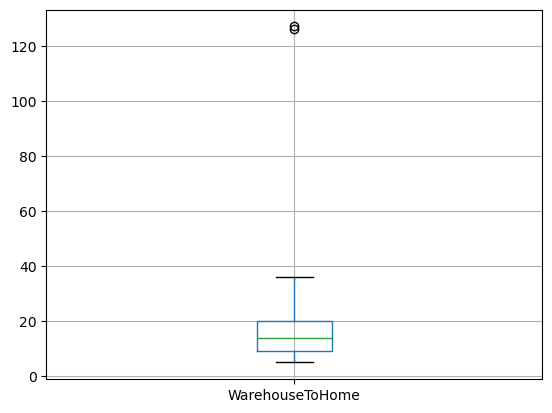

In [27]:
import matplotlib.pyplot as plt
df.boxplot(column="WarehouseToHome")
plt.show()

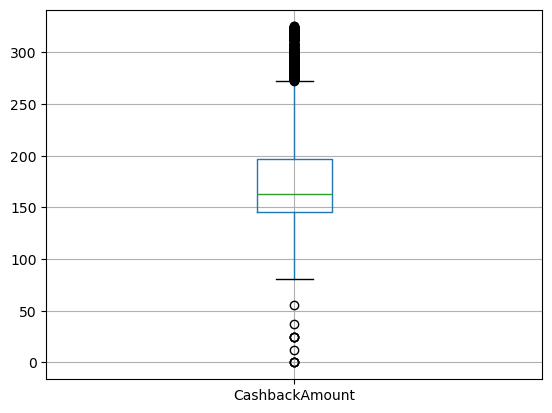

In [28]:
df.boxplot(column='CashbackAmount')
plt.show()

In [107]:
df_encoded.to_csv("dataset1_clean.csv", index=False)

Outlier Analysis

Boxplots were used to identify potential outliers in the dataset.

• The WarehouseToHome variable contains a small number of extreme values, indicating that a few customers live significantly farther from the warehouse than the majority of customers.

• The CashbackAmount variable contains several outliers on both the lower and upper ends of the distribution. These extreme values may influence the mean and explain why the mean is higher than the median.

The outliers were retained because they may represent legitimate customer behavior rather than data entry errors.

# DATASET 2 : E-commerce User Behavior Dataset (for AARRR)

In [29]:
df2 = pd.read_csv("E_commerce_dataset2.csv")

C:\Users\azade\AppData\Local\Temp\ipykernel_22496\2174409576.py:1: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("E_commerce_dataset2.csv")


In [30]:
df2.head()

,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Age,Education,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Browsing Time (min),Like,Share,Add to Cart
0,LS-001,Lane Daniels,Consumer,Brisbane,Queensland,Australia,Oceania,Male,22,Associate Degree,...,$140.00,2,0.05,$46.00,$4.60,Medium,14.7,1,1,1
1,IZ-002,Alvarado Kriz,Home Office,Berlin,Berlin,Germany,Central,Male,32,Bachelor,...,$211.00,3,0.03,$112.00,$11.20,Medium,15.0,0,0,1
2,EN-003,Moon Weien,Consumer,Porirua,Wellington,New Zealand,Oceania,Male,21,High School,...,$117.00,5,0.01,$31.20,$3.10,Critical,19.9,1,1,1
3,AN-004,Sanchez Bergman,Corporate,Kabul,Kabul,Afghanistan,Central Asia,Male,22,Bachelor,...,$118.00,2,0.05,$26.20,$2.60,High,15.8,1,1,1
4,ON-005,Rowe Jackson,Corporate,Townsville,Queensland,Australia,Oceania,Male,28,Associate Degree,...,$250.00,1,0.04,$160.00,$16.00,Critical,18.1,1,1,1


In [31]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51289 entries, 0 to 51288
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer ID          51289 non-null  object 
 1   Customer Name        51289 non-null  object 
 2   Segment              51289 non-null  object 
 3   City                 51289 non-null  object 
 4   State                51289 non-null  object 
 5   Country              51289 non-null  object 
 6   Region               51215 non-null  object 
 7   Gender               51289 non-null  object 
 8   Age                  51289 non-null  int64  
 9   Education            51289 non-null  object 
 10  Marital Status       51289 non-null  object 
 11  Order ID             51289 non-null  object 
 12  Order Date           51289 non-null  object 
 13  Months               51289 non-null  object 
 14  Ship Mode            51289 non-null  object 
 15  Product Category     51289 non-null 

In [32]:
df2.shape

(51289, 27)

In [33]:
df2.describe()

,Age,Browsing Time (min),Like,Share,Add to Cart
count,51289.000000,51289.000000,51289.000000,51289.000000,51289.000000
mean,31.315428,17.275973,0.567315,0.505274,0.666732
std,11.900634,9.674191,0.495453,0.499977,0.471386
min,18.000000,1.000000,0.000000,0.000000,0.000000
25%,22.000000,9.300000,0.000000,0.000000,0.000000
50%,28.000000,16.500000,1.000000,1.000000,1.000000
75%,37.000000,24.600000,1.000000,1.000000,1.000000
max,70.000000,40.000000,1.000000,1.000000,1.000000


## Who, What, How

### Who
The dataset contains records of e-commerce customers and their purchasing behavior.

### What
The dataset includes customer demographics, location information, product purchases, sales information, shipping details, and engagement metrics such as browsing time, likes, shares, and add-to-cart actions.

### How
The data appears to have been collected from an e-commerce platform to analyze customer behavior and support AARRR (Acquisition, Activation, Retention, Revenue, Referral) analytics.

In [34]:
df2.duplicated().sum()

np.int64(0)

In [35]:
df2.isnull().sum()

Customer ID             0
Customer Name           0
Segment                 0
City                    0
State                   0
Country                 0
Region                 74
Gender                  0
Age                     0
Education               0
Marital Status          0
Order ID                0
Order Date              0
Months                  0
Ship Mode               0
Product Category        0
Product                 0
Sales                   0
Quantity                1
Discount                0
Profit                  0
Shipping Cost           0
Order Priority          2
Browsing Time (min)     0
Like                    0
Share                   0
Add to Cart             0
dtype: int64

In [36]:
(df2.isnull().sum()/ len(df2))*100

Customer ID            0.000000
Customer Name          0.000000
Segment                0.000000
City                   0.000000
State                  0.000000
Country                0.000000
Region                 0.144280
Gender                 0.000000
Age                    0.000000
Education              0.000000
Marital Status         0.000000
Order ID               0.000000
Order Date             0.000000
Months                 0.000000
Ship Mode              0.000000
Product Category       0.000000
Product                0.000000
Sales                  0.000000
Quantity               0.001950
Discount               0.000000
Profit                 0.000000
Shipping Cost          0.000000
Order Priority         0.003899
Browsing Time (min)    0.000000
Like                   0.000000
Share                  0.000000
Add to Cart            0.000000
dtype: float64

In [37]:
df2[["Sales","Quantity","Discount","Profit","Shipping Cost"]].head()

,Sales,Quantity,Discount,Profit,Shipping Cost
0,$140.00,2,0.05,$46.00,$4.60
1,$211.00,3,0.03,$112.00,$11.20
2,$117.00,5,0.01,$31.20,$3.10
3,$118.00,2,0.05,$26.20,$2.60
4,$250.00,1,0.04,$160.00,$16.00


In [38]:
df2['Sales'].unique()[:20]

array(['$140.00 ', '$211.00 ', '$117.00 ', '$118.00 ', '$250.00 ',
       '$72.00 ', '$54.00 ', '$114.00 ', '$231.00 ', '0.xf', '$220.00 ',
       '$104.00 ', '$149.00 ', '$222.00 ', '$199.00 ', '$111.00 ',
       '$33.00 ', '$83.00 ', '$192.00 ', '$65.00 '], dtype=object)

In [39]:
df2[df2['Sales'] == '0.xf']

,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Age,Education,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Browsing Time (min),Like,Share,Add to Cart
792,RE-00197,Schwartz Laware,Consumer,Philadelphia,Pennsylvania,United States,East,Female,18,High School,...,0.xf,3,0.01,$124.70,$12.50,Critical,27.9,0,0,0


In [40]:
df2[df2['Sales'].str.contains('xf', na=False)]

,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Age,Education,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Browsing Time (min),Like,Share,Add to Cart
792,RE-00197,Schwartz Laware,Consumer,Philadelphia,Pennsylvania,United States,East,Female,18,High School,...,0.xf,3,0.01,$124.70,$12.50,Critical,27.9,0,0,0


In [41]:
df2['Sales'] = pd.to_numeric(
    df2['Sales'].str.replace('$','',regex=False),
    errors='coerce')

In [42]:
df2['Sales'].isnull().sum()

np.int64(1)

In [43]:
df2['Sales'].fillna(df2['Sales'].median())

0        140.0
1        211.0
2        117.0
3        118.0
4        250.0
         ...  
51284     85.0
51285     85.0
51286     85.0
51287     85.0
51288     85.0
Name: Sales, Length: 51289, dtype: float64

In [44]:
df2['Sales'].isnull().sum()

np.int64(1)

In [45]:

df2['Profit'] = pd.to_numeric(df2['Profit'].str.replace('$', '', regex=False),errors='coerce')
df2['Shipping Cost'] = pd.to_numeric(df2['Shipping Cost'].str.replace('$','', regex=False),errors='coerce')

In [46]:
df2[['Sales','Profit','Shipping Cost']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51289 entries, 0 to 51288
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sales          51288 non-null  float64
 1   Profit         51289 non-null  float64
 2   Shipping Cost  51288 non-null  float64
dtypes: float64(3)
memory usage: 1.2 MB


In [47]:
df2[['Sales','Profit','Shipping Cost']].isnull().sum()

Sales            1
Profit           0
Shipping Cost    1
dtype: int64

In [48]:
df2['Shipping Cost'] =df2['Shipping Cost'].fillna(df2['Shipping Cost'].median())

In [49]:
df2[['Sales','Profit','Shipping Cost']].isnull().sum()

Sales            1
Profit           0
Shipping Cost    0
dtype: int64

In [50]:
df2['Region'] = df2['Region'].fillna(df2['Region'].mode()[0])
df2['Quantity'] = df2['Quantity'].fillna(df2['Quantity'].mode()[0])
df2['Order Priority'] = df2['Order Priority'].fillna(df2['Order Priority'].mode()[0])

In [51]:
df2.isnull().sum()

Customer ID            0
Customer Name          0
Segment                0
City                   0
State                  0
Country                0
Region                 0
Gender                 0
Age                    0
Education              0
Marital Status         0
Order ID               0
Order Date             0
Months                 0
Ship Mode              0
Product Category       0
Product                0
Sales                  1
Quantity               0
Discount               0
Profit                 0
Shipping Cost          0
Order Priority         0
Browsing Time (min)    0
Like                   0
Share                  0
Add to Cart            0
dtype: int64

In [52]:
df2.describe()

,Age,Sales,Profit,Shipping Cost,Browsing Time (min),Like,Share,Add to Cart
count,51289.000000,51288.000000,51289.000000,51289.000000,51289.000000,51289.000000,51289.000000,51289.000000
mean,31.315428,156.432265,72.726294,7.273035,17.275973,0.567315,0.505274,0.666732
std,11.900634,65.781159,49.097484,4.908429,9.674191,0.495453,0.499977,0.471386
min,18.000000,33.000000,0.500000,0.100000,1.000000,0.000000,0.000000,0.000000
25%,22.000000,109.000000,25.700000,2.600000,9.300000,0.000000,0.000000,0.000000
50%,28.000000,159.000000,67.000000,6.700000,16.500000,1.000000,1.000000,1.000000
75%,37.000000,218.000000,120.600000,12.100000,24.600000,1.000000,1.000000,1.000000
max,70.000000,250.000000,167.500000,16.800000,40.000000,1.000000,1.000000,1.000000


In [53]:
df2.describe(include='object')

,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Education,Marital Status,Order ID,Order Date,Months,Ship Mode,Product Category,Product,Quantity,Discount,Order Priority
count,51289,51289,51289,51289,51289,51289,51289,51289,51289,51289,51289,51289,51289,51289,51289,51289,51289,51289,51289
unique,795,795,3,548,320,84,14,2,5,2,51273,664,12,5,4,42,11,11,4
top,LL-0092,Mcclain O'Donnell,Consumer,New York City,California,United States,Central,Female,Bachelor,Married,FA-2024-20241,2022/3/15,Jul,Standard Class,Fashion,Sports Wear,4,0.02,Medium
freq,108,108,26518,1188,2615,9900,10978,26113,14122,27736,2,651,4445,30775,30775,2827,6633,6637,29435


In [54]:
cat_cols = [
    'Segment',
    'Region',
    'Gender',
    'Education',
    'Marital Status',
    'Ship Mode',
    'Product Category',
    'Order Priority'
]
for col in cat_cols:
    print("\n"+ "="*50)
    print(col)
    print(df2[col].value_counts())


Segment
Segment
Consumer       26518
Corporate      15429
Home Office     9342
Name: count, dtype: int64

Region
Region
Central           10978
South              6673
North              5458
Oceania            4245
North Asia         3822
West               3443
Southeast Asia     3310
EMEA               3257
Africa             3238
East               3027
Central Asia       2297
Caribbean          1146
Canada              337
So3th                58
Name: count, dtype: int64

Gender
Gender
Female    26113
Male      25176
Name: count, dtype: int64

Education
Education
Bachelor            14122
High School         10613
Doctorate            9505
Associate Degree     8825
Master               8224
Name: count, dtype: int64

Marital Status
Marital Status
Married    27736
Single     23553
Name: count, dtype: int64

Ship Mode
Ship Mode
Standard Class    30775
Second Class      10309
First Class        7503
Same Day           2701
45788                 1
Name: count, dtype: int64

Product 

In [55]:
df2[df2['Ship Mode'] == '45788']

,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Age,Education,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Browsing Time (min),Like,Share,Add to Cart
1023,ER-00161,Montoya Ritter,Corporate,Barcelona,Catalonia,Spain,South,Female,18,High School,...,114.0,5,0.05,5.5,0.6,Medium,27.4,0,0,0


In [56]:
df2['Ship Mode'] = df2['Ship Mode'].replace('45788', np.nan)

In [57]:
df2['Ship Mode'].isnull().sum()

np.int64(1)

In [58]:
df2['Ship Mode'] = df2['Ship Mode'].fillna(df2['Ship Mode'].mode()[0])

In [59]:
df2['Region'] = df2['Region'].replace({
    'So3th' : 'South'})

In [60]:
df2['Region'].value_counts()

Region
Central           10978
South              6731
North              5458
Oceania            4245
North Asia         3822
West               3443
Southeast Asia     3310
EMEA               3257
Africa             3238
East               3027
Central Asia       2297
Caribbean          1146
Canada              337
Name: count, dtype: int64

### Categorical Variable Analysis

Categorical variables were examined using frequency distributions.

- Most customers belong to the Consumer segment.
- Female customers slightly outnumber male customers.
- Bachelor degree holders represent the largest education group.
- Most orders use Standard Class shipping.
- Fashion is the most common product category.
- Medium priority orders account for the majority of transactions.



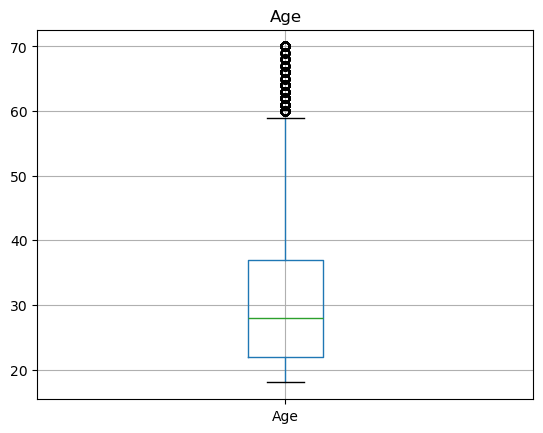

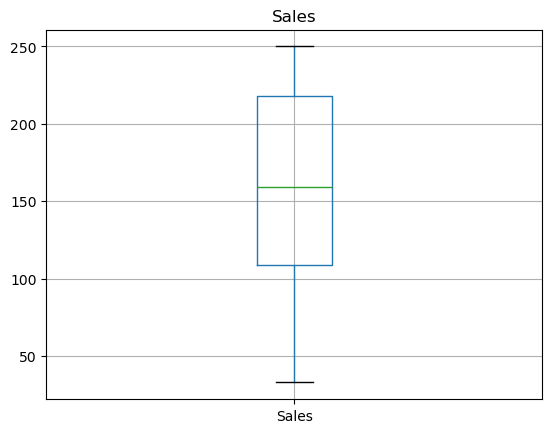

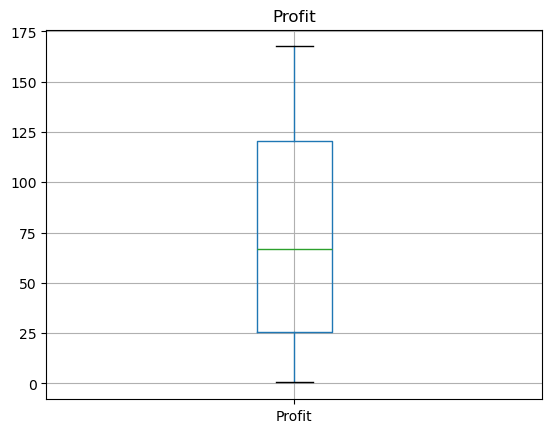

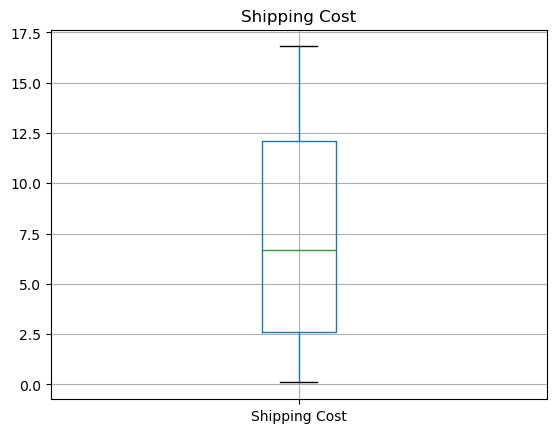

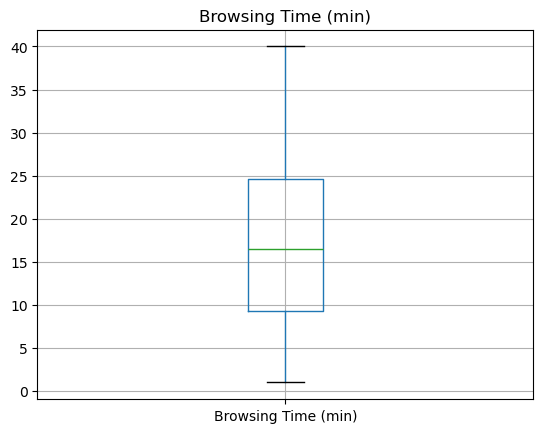

In [61]:
num_cols =[
    'Age',
    'Sales',
    'Profit',
    'Shipping Cost',
    'Browsing Time (min)'
]
for col in num_cols:
    df2.boxplot(column=col)
    plt.title(col)
    plt.show()

In [62]:
df2.duplicated().sum()

np.int64(0)

In [63]:
df2.to_csv("dataset2_clean_nonencoded.csv", index=False)

### Outlier Analysis

Boxplots were used to examine potential outliers in the numerical variables.

- The Age variable contains several upper-end outliers representing older customers. These values appear realistic and likely reflect genuine customer demographics.
- Sales, Profit, Shipping Cost, and Browsing Time (min) show relatively balanced distributions with no significant outliers.
- No extreme values were identified that would suggest data entry errors.

All observations were retained because the detected values appear to represent valid customer behavior.

In [66]:
df2_encoded = pd.get_dummies(
    df2,
    columns=[
        'Segment',
        'Region',
        'Gender',
        'Education',
        'Marital Status',
        'Ship Mode',
        'Product Category',
        'Order Priority'
    ],
    drop_first=True
)

df2_encoded.head()

,Customer ID,Customer Name,City,State,Country,Age,Order ID,Order Date,Months,Product,...,Marital Status_Single,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Product Category_Electronic,Product Category_Fashion,Product Category_Home & Furniture,Order Priority_High,Order Priority_Low,Order Priority_Medium
0,LS-001,Lane Daniels,Brisbane,Queensland,Australia,22,AU-2024-1,2024/9/15,Nov,Car Media Players,...,False,False,False,False,False,False,False,False,False,True
1,IZ-002,Alvarado Kriz,Berlin,Berlin,Germany,32,AU-2024-2,2024/6/30,Jun,Car Speakers,...,False,False,False,False,False,False,False,False,False,True
2,EN-003,Moon Weien,Porirua,Wellington,New Zealand,21,AU-2024-3,2024/5/15,Dec,Car Body Covers,...,True,False,False,False,False,False,False,False,False,False
3,AN-004,Sanchez Bergman,Kabul,Kabul,Afghanistan,22,AU-2024-4,2024/9/15,May,Car & Bike Care,...,False,False,False,False,False,False,False,True,False,False
4,ON-005,Rowe Jackson,Townsville,Queensland,Australia,28,AU-2024-5,2023/9/15,Jul,Tyre,...,True,False,False,False,False,False,False,False,False,False


In [67]:
df2_encoded.shape

(51289, 48)

In [108]:
df2_encoded.to_csv("dataset2_clean.csv", index=False)

### Encoding

Categorical variables with a small number of unique categories were encoded using one-hot encoding.

The following variables were encoded:
- Segment
- Gender
- Education
- Marital Status
- Ship Mode
- Product Category
- Order Priority

High-cardinality columns such as Customer ID, Customer Name, City, State, Country, Product, and Order ID were not encoded because they contain a large number of unique values and would unnecessarily increase the dimensionality of the dataset.

After encoding, the dataset expanded from 27 columns to 48 columns.

The encoded dataset is now ready for machine learning and further analysis.

# DataSet 3 : Sales and Customer Insights Dataset


In [64]:
df3 = pd.read_csv("sales_and_customer_insights_dataset3.csv")

In [65]:
df3.head()

,Customer_ID,Product_ID,Transaction_ID,Purchase_Frequency,Average_Order_Value,Most_Frequent_Category,Time_Between_Purchases,Region,Churn_Probability,Lifetime_Value,Launch_Date,Peak_Sales_Date,Season,Preferred_Purchase_Times,Retention_Strategy
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,Electronics,45,South America,0.98,952.81,2020-03-14,2023-09-11,Winter,Afternoon,Loyalty Program
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,Clothing,6,South America,0.66,5427.51,2022-10-15,2023-01-02,Spring,Afternoon,Discount
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,Sports,23,Asia,0.60,3994.80,2021-11-30,2023-04-06,Winter,Evening,Loyalty Program
3,CUST_IGH8G3,PROD_3IIAJN,TRANS_45V00G,12,70.34,Clothing,5,North America,0.78,4880.01,2022-03-20,2023-03-23,Spring,Evening,Discount
4,CUST_OK6PUM,PROD_VMIWD2,TRANS_ZAK760,18,42.39,Electronics,10,North America,0.52,8557.70,2022-11-09,2023-10-28,Spring,Morning,Discount


In [66]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               10000 non-null  object 
 1   Product_ID                10000 non-null  object 
 2   Transaction_ID            10000 non-null  object 
 3   Purchase_Frequency        10000 non-null  int64  
 4   Average_Order_Value       10000 non-null  float64
 5   Most_Frequent_Category    10000 non-null  object 
 6   Time_Between_Purchases    10000 non-null  int64  
 7   Region                    10000 non-null  object 
 8   Churn_Probability         10000 non-null  float64
 9   Lifetime_Value            10000 non-null  float64
 10  Launch_Date               10000 non-null  object 
 11  Peak_Sales_Date           10000 non-null  object 
 12  Season                    10000 non-null  object 
 13  Preferred_Purchase_Times  10000 non-null  object 
 14  Retenti

## Who, What, How

### Who
The dataset represents customers and their purchasing activities across different products, regions, and marketing strategies.

### What
The dataset contains customer behavior metrics, transaction information, product details, purchase patterns, churn probability, customer lifetime value, and retention strategies.

### How
The data appears to have been collected from an e-commerce environment to analyze customer purchasing behavior, customer retention, churn probability, and overall customer value. The dataset can be used for customer segmentation, retention analysis, and predictive modeling.

In [67]:
df3.shape

(10000, 15)

In [68]:
df3.describe()

,Purchase_Frequency,Average_Order_Value,Time_Between_Purchases,Churn_Probability,Lifetime_Value
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,9.955700,110.006022,46.885300,0.501552,5031.930567
std,5.526209,52.096870,24.711746,0.288289,2865.420299
min,1.000000,20.010000,5.000000,0.000000,100.160000
25%,5.000000,65.262500,25.000000,0.250000,2518.775000
50%,10.000000,109.930000,47.000000,0.500000,5012.180000
75%,15.000000,155.480000,68.000000,0.750000,7526.232500
max,19.000000,199.960000,89.000000,1.000000,9999.760000


In [69]:
df3.describe(include='object')

,Customer_ID,Product_ID,Transaction_ID,Most_Frequent_Category,Region,Launch_Date,Peak_Sales_Date,Season,Preferred_Purchase_Times,Retention_Strategy
count,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
unique,10000,10000,10000,4,4,1097,365,4,3,3
top,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,Electronics,Europe,2021-12-22,2023-10-28,Winter,Evening,Loyalty Program
freq,1,1,1,2567,2547,19,45,2534,3433,3364


In [70]:
df3.duplicated().sum()

np.int64(0)

In [71]:
(df3.isnull().sum()/ len(df3))*100

Customer_ID                 0.0
Product_ID                  0.0
Transaction_ID              0.0
Purchase_Frequency          0.0
Average_Order_Value         0.0
Most_Frequent_Category      0.0
Time_Between_Purchases      0.0
Region                      0.0
Churn_Probability           0.0
Lifetime_Value              0.0
Launch_Date                 0.0
Peak_Sales_Date             0.0
Season                      0.0
Preferred_Purchase_Times    0.0
Retention_Strategy          0.0
dtype: float64

In [72]:
cat_cols = [
    "Most_Frequent_Category",
    "Region",
    "Season",
    "Preferred_Purchase_Times",
    "Retention_Strategy"
]
for col in cat_cols:
    print("="*50)
    print(col)
    print(df3[col].value_counts())

Most_Frequent_Category
Most_Frequent_Category
Electronics    2567
Clothing       2510
Home           2476
Sports         2447
Name: count, dtype: int64
Region
Region
Europe           2547
South America    2527
Asia             2472
North America    2454
Name: count, dtype: int64
Season
Season
Winter    2534
Summer    2521
Fall      2502
Spring    2443
Name: count, dtype: int64
Preferred_Purchase_Times
Preferred_Purchase_Times
Evening      3433
Afternoon    3354
Morning      3213
Name: count, dtype: int64
Retention_Strategy
Retention_Strategy
Loyalty Program    3364
Email Campaign     3359
Discount           3277
Name: count, dtype: int64


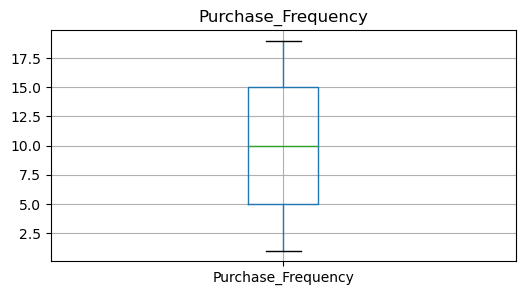

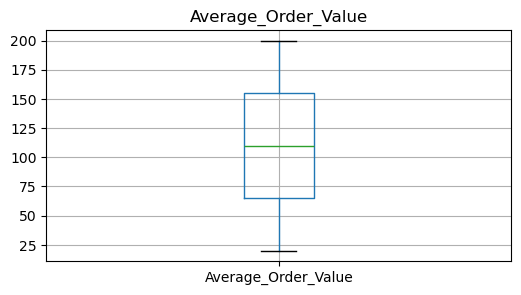

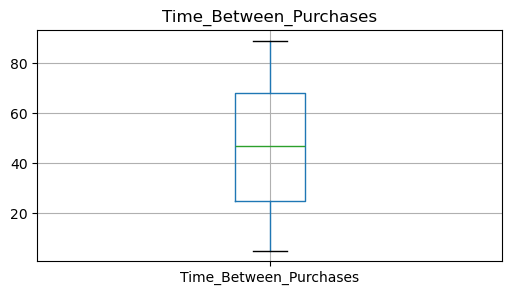

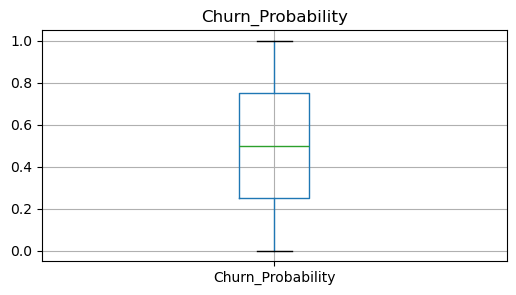

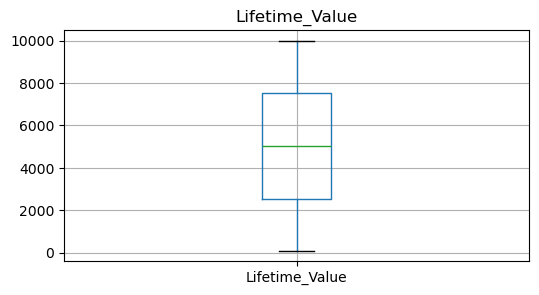

In [73]:
num_cols =[
    "Purchase_Frequency",
    "Average_Order_Value",
    "Time_Between_Purchases",
    "Churn_Probability",
    "Lifetime_Value"
]
for col in num_cols:
    plt.figure(figsize=(6,3))
    df3.boxplot([col])
    plt.title(col)
    plt.show()

In [74]:
df3.to_csv("dataset3_clean_nonencoded.csv", index=False)

### Data Cleaning Summary

- Dataset contains 10,000 records and 15 columns.
- No missing values were detected.
- No duplicate records were found.
- Categorical variables showed balanced distributions across categories.
- Numerical variables did not exhibit significant outliers based on boxplot analysis.
- The dataset was considered clean and ready for encoding and further analysis.

In [78]:
df3_encoded = pd.get_dummies(
    df3,
    columns=[
        "Most_Frequent_Category",
        "Region",
        "Season",
        "Preferred_Purchase_Times",
        "Retention_Strategy"
    ],
    drop_first=True)
df3_encoded.head()

,Customer_ID,Product_ID,Transaction_ID,Purchase_Frequency,Average_Order_Value,Time_Between_Purchases,Churn_Probability,Lifetime_Value,Launch_Date,Peak_Sales_Date,...,Region_Europe,Region_North America,Region_South America,Season_Spring,Season_Summer,Season_Winter,Preferred_Purchase_Times_Evening,Preferred_Purchase_Times_Morning,Retention_Strategy_Email Campaign,Retention_Strategy_Loyalty Program
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,45,0.98,952.81,2020-03-14,2023-09-11,...,False,False,True,False,False,True,False,False,False,True
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,6,0.66,5427.51,2022-10-15,2023-01-02,...,False,False,True,True,False,False,False,False,False,False
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,23,0.60,3994.80,2021-11-30,2023-04-06,...,False,False,False,False,False,True,True,False,False,True
3,CUST_IGH8G3,PROD_3IIAJN,TRANS_45V00G,12,70.34,5,0.78,4880.01,2022-03-20,2023-03-23,...,False,True,False,True,False,False,True,False,False,False
4,CUST_OK6PUM,PROD_VMIWD2,TRANS_ZAK760,18,42.39,10,0.52,8557.70,2022-11-09,2023-10-28,...,False,True,False,True,False,False,False,True,False,False


In [79]:
df3_encoded.shape

(10000, 23)

In [80]:
df3_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Customer_ID                         10000 non-null  object 
 1   Product_ID                          10000 non-null  object 
 2   Transaction_ID                      10000 non-null  object 
 3   Purchase_Frequency                  10000 non-null  int64  
 4   Average_Order_Value                 10000 non-null  float64
 5   Time_Between_Purchases              10000 non-null  int64  
 6   Churn_Probability                   10000 non-null  float64
 7   Lifetime_Value                      10000 non-null  float64
 8   Launch_Date                         10000 non-null  object 
 9   Peak_Sales_Date                     10000 non-null  object 
 10  Most_Frequent_Category_Electronics  10000 non-null  bool   
 11  Most_Frequent_Category_Home         10000 

In [109]:
df3_encoded.to_csv("dataset3_clean.csv", index=False)

### Encoding

Categorical variables were transformed using One-Hot Encoding to convert textual categories into machine-readable numerical features.

Encoded columns:
- Most_Frequent_Category
- Region
- Season
- Preferred_Purchase_Times
- Retention_Strategy

Identifier and date-related columns such as Customer_ID, Product_ID, Transaction_ID, Launch_Date, and Peak_Sales_Date were not encoded because they do not provide meaningful predictive information.

The final encoded dataset contains 10,000 rows and 23 columns.

## Data Cleaning Summary

- The dataset contains 10,000 records and 15 variables.
- No missing values were identified.
- No duplicate records were found.
- Categorical variables showed balanced distributions across categories.
- No significant outliers were detected in the numerical variables.
- The dataset was considered clean and ready for further analysis and machine learning applications.

# Dataset 4: Ecommerce Customer Behavior Dataset


In [75]:
df4 = pd.read_csv("ecommerce_customer_churn_dataset_dataset4.csv")

In [76]:
df4.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


## Who/What/How


### Who

This dataset represents 50,000 e-commerce customers from multiple countries (USA, UK, Germany, Canada, India, Japan, France, and Australia). It contains customer demographic, engagement, purchasing, and churn-related information collected from an online retail/subscription platform.


### What

The dataset contains 25 features describing customer behavior and engagement, including:

* Customer demographics (Age, Gender, Country, City, Membership Years)
* Platform engagement (Login Frequency, Session Duration, Pages per Session, Wishlist Items, Email Open Rate, etc.)
* Purchase behavior (Total Purchases, Average Order Value, Return Rate, Discount Usage Rate, etc.)
* Customer service interactions
* Financial information
* Customer churn status (target variable)

The target variable is Churned:

* 0 = Active Customer
* 1 = Churned Customer


### How

The data was generated to provide a 360-degree view of customer interactions and engagement patterns across an e-commerce platform. It combines behavioral, transactional, demographic, and customer service metrics to support customer analytics, churn prediction, segmentation, and business intelligence applications.

In [77]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [78]:
df4.shape

(50000, 25)

In [79]:
df4.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [80]:
df4.describe(include='object')

,Gender,Country,City,Signup_Quarter
count,50000,50000,50000,50000
unique,3,8,40,4
top,Female,USA,Houston,Q3
freq,25116,17384,3549,12558


In [81]:
df4.isnull().sum()

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

In [82]:
(df4.isnull().sum()/ len(df4))*100

Age                               4.990
Gender                            0.000
Country                           0.000
City                              0.000
Membership_Years                  0.000
Login_Frequency                   0.000
Session_Duration_Avg              6.798
Pages_Per_Session                 6.000
Cart_Abandonment_Rate             0.000
Wishlist_Items                    8.000
Total_Purchases                   0.000
Average_Order_Value               0.000
Days_Since_Last_Purchase          6.000
Discount_Usage_Rate               7.000
Returns_Rate                      8.982
Email_Open_Rate                   5.056
Customer_Service_Calls            0.336
Product_Reviews_Written           7.000
Social_Media_Engagement_Score    12.000
Mobile_App_Usage                 10.000
Payment_Method_Diversity          5.000
Lifetime_Value                    0.000
Credit_Balance                   11.000
Churned                           0.000
Signup_Quarter                    0.000


### Missing Values Analysis

The dataset contains missing values in several numerical columns. Most missing values are below 10%, which suggests that imputation is more appropriate than deleting rows.

Key observations:

- Social_Media_Engagement_Score has the highest missing rate (12.0%).
- Credit_Balance contains 11.0% missing values.
- Mobile_App_Usage contains 10.0% missing values.
- Returns_Rate contains 8.98% missing values.
- Wishlist_Items contains 8.0% missing values.
- Several other engagement and purchasing variables contain between 5% and 7% missing values.
- Categorical variables (Gender, Country, City, Signup_Quarter) have no missing values.

Since the percentage of missing data is relatively moderate, missing numerical values will be imputed rather than removing records.

In [83]:
df4.duplicated().sum()

np.int64(0)

In [84]:
for col in df4.select_dtypes(include='object').columns:
    print('\n'+"="*50,col)
    print(df4[col].value_counts())


================================================== Gender
Gender
Female    25116
Male      23947
Other       937
Name: count, dtype: int64

================================================== Country
Country
USA          17384
UK            7534
Canada        6023
Germany       4925
Australia     4061
France        4013
India         3512
Japan         2548
Name: count, dtype: int64

================================================== City
City
Houston        3549
Phoenix        3490
New York       3477
Chicago        3475
Los Angeles    3393
Manchester     1576
Birmingham     1535
Leeds          1529
London         1458
Glasgow        1436
Montreal       1247
Toronto        1209
Calgary        1204
Ottawa         1182
Vancouver      1181
Cologne        1033
Hamburg        1026
Berlin         1013
Munich          960
Frankfurt       893
Lyon            830
Sydney          828
Perth           817
Adelaide        817
Toulouse        815
Melbourne       805
Nice            799
Brisbane    

### Data Quality Assessment

- Dataset contains 50,000 customer records and 25 variables.
- No duplicate records were found.
- Several numerical variables contain missing values, ranging from less than 1% to 12%.
- Categorical variables (Gender, Country, City, Signup_Quarter) contain no missing values.
- The dataset covers customers from 8 countries and 40 cities.
- Customer signups are evenly distributed across all four quarters.
- Gender distribution is relatively balanced between male and female customers.

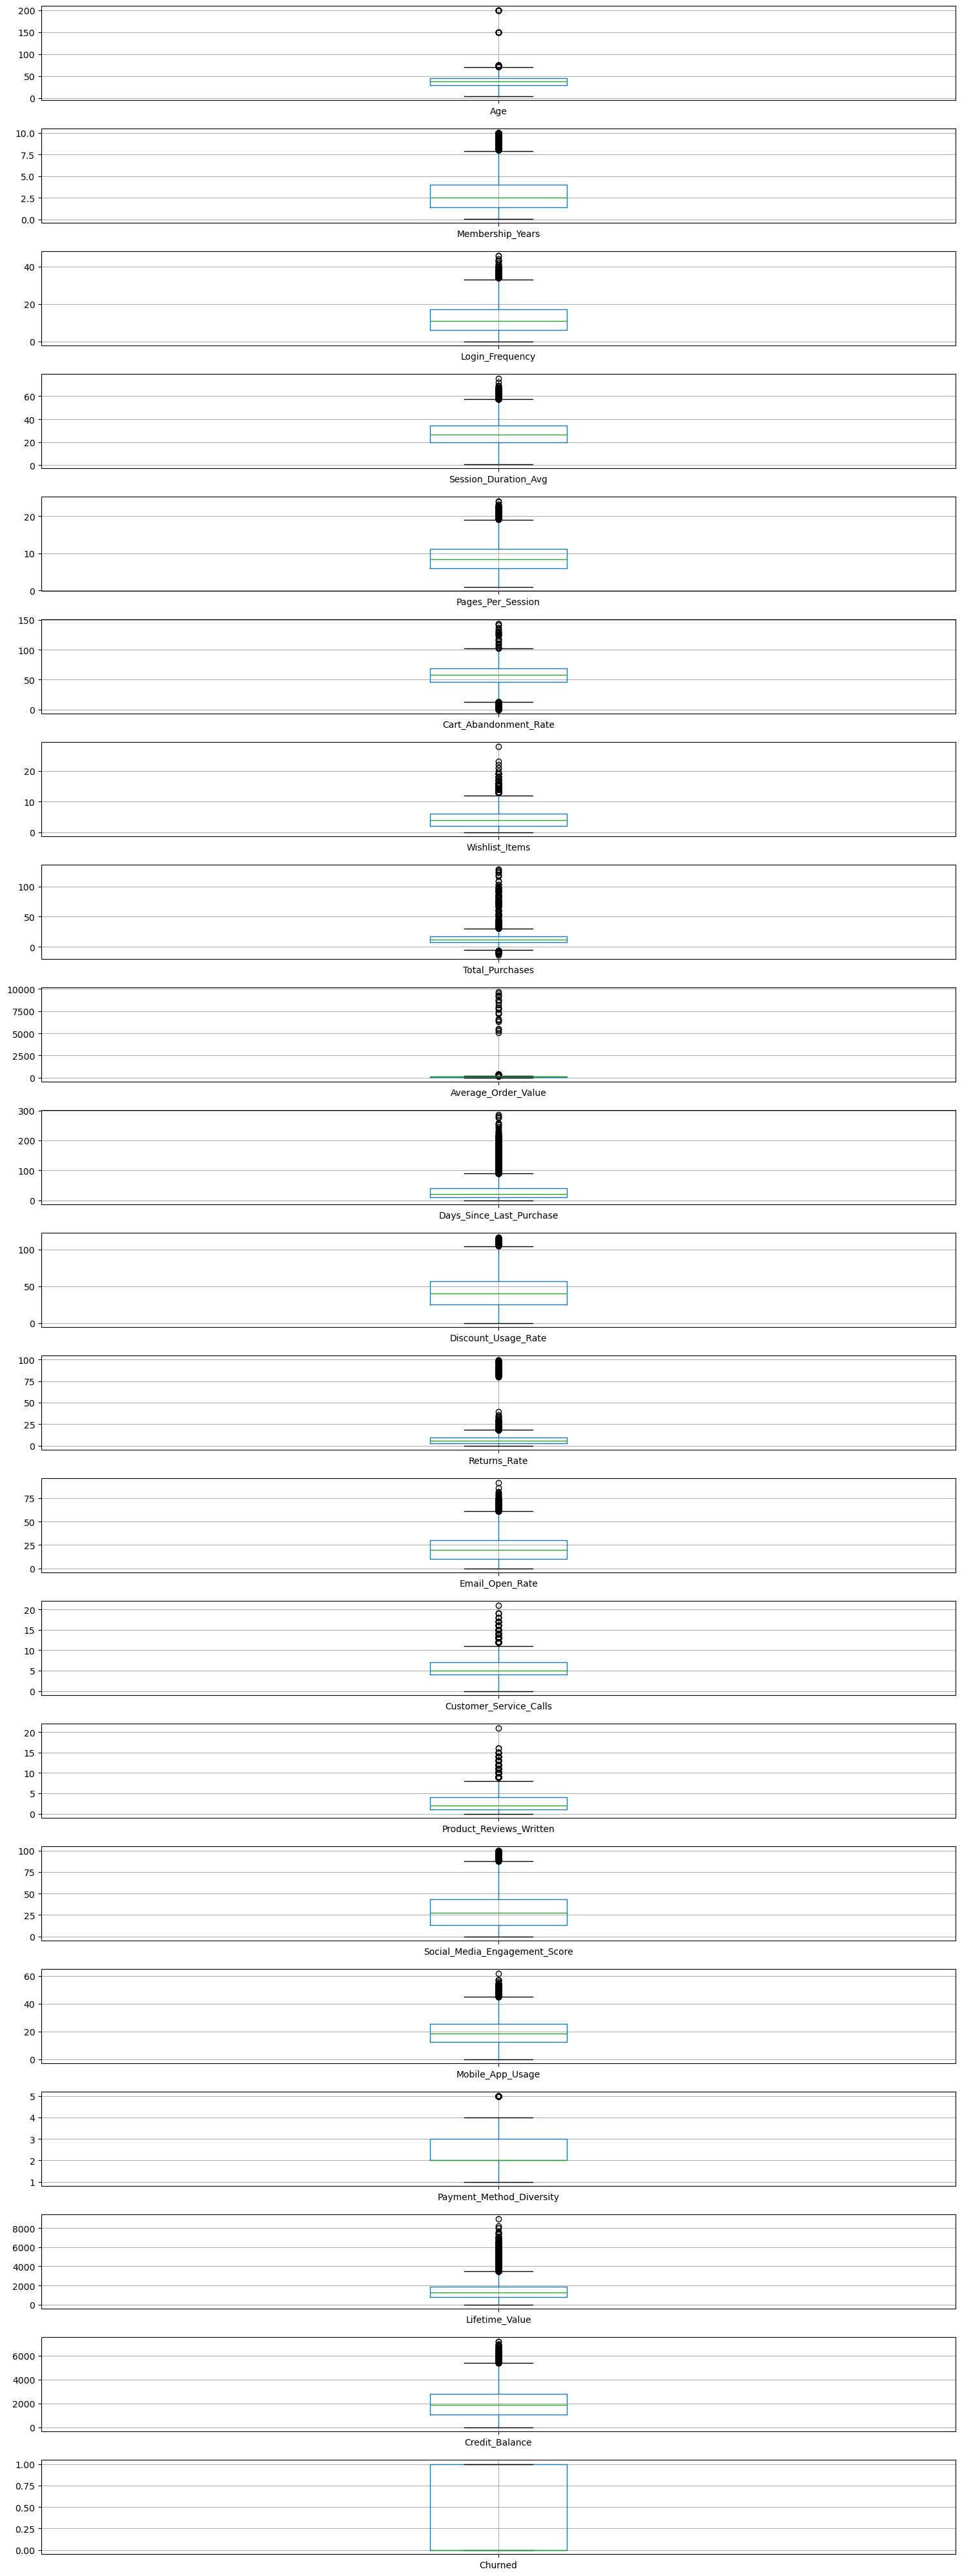

In [85]:
num_cols = df4.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(15,40))

for i,col in enumerate(num_cols,1):
    plt.subplot(len(num_cols),1,i)
    df4.boxplot([col])

plt.tight_layout()
plt.show()

### Outlier Analysis

Boxplots were used to identify potential outliers in numerical variables.

Observations:

- Age contains several extreme values, including ages above 100 and one value close to 200, which are likely data entry errors.
- Total_Purchases contains a few negative values, which are not realistic and may indicate data quality issues.
- Lifetime_Value and Credit_Balance contain several high-value observations, but these may represent high-value customers and should be retained.
- Customer engagement variables such as Login_Frequency, Session_Duration_Avg, Wishlist_Items, and Social_Media_Engagement_Score show moderate outliers that appear to be valid customer behavior.
- Churned is a binary target variable and does not require outlier treatment.

Because most outliers appear to represent legitimate customer behavior, they will be retained for analysis. Only clearly unrealistic values (e.g., Age > 100 or negative purchase counts) may require additional investigation.

In [88]:
# Missin value treatment
num_cols = df4.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
   df4[col] = df4[col].fillna(df4[col].median())

In [89]:
df4.isnull().sum()

Age                              0
Gender                           0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
Signup_Quarter                   0
dtype: int64

### Missing Value Treatment

Missing values were identified in several numerical columns. Since most missing rates were moderate and the dataset contains outliers, missing numerical values were filled using the median instead of the mean. The median was selected because it is less sensitive to extreme values.

After imputation, all missing values were successfully removed from the dataset.

In [90]:
df4[df4['Age'] > 100]['Age'].count()

np.int64(20)

In [91]:
df4[df4['Age'] < 18]['Age'].count()

np.int64(30)

In [92]:
df4[df4['Total_Purchases'] < 0 ]['Total_Purchases'].count()

np.int64(40)

In [93]:
20 +30+40

90

In [94]:
(90 / 50000)*100

0.18

In [95]:
df4 = df4[(df4['Age'] >=18) & (df4['Age'] <= 100)]
df4 = df4[df4['Total_Purchases'] >= 0]

In [96]:
df4.shape

(49910, 25)

In [97]:
df4.to_csv("dataset4_clean_nonencoded.csv", index=False)

### Data Quality Corrections

Several unrealistic values were identified during data quality assessment.

- 20 records contained ages greater than 100.
- 30 records contained ages below 18.
- 40 records contained negative purchase counts.

These records were removed because they represent invalid values rather than legitimate customer behavior. The affected records accounted for less than 0.2% of the dataset and therefore had minimal impact on the overall analysis.

In [101]:
df4_encoded = pd.get_dummies(
    df4,
    columns=['Gender',
             'Country',
             'City',
             'Signup_Quarter'
            ],
    drop_first=True
)
df4_encoded.head()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,City_Phoenix,City_Sydney,City_Tokyo,City_Toronto,City_Toulouse,City_Vancouver,City_Yokohama,Signup_Quarter_Q2,Signup_Quarter_Q3,Signup_Quarter_Q4
0,43.0,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,...,False,False,False,False,False,False,False,False,False,False
1,36.0,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,...,False,False,False,False,False,False,False,False,False,True
2,45.0,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,...,False,False,False,False,False,True,False,False,False,True
3,56.0,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,47.0,...,False,False,False,False,False,False,False,False,False,False
4,35.0,3.1,29.0,51.4,8.4,19.1,9.0,32.5,141.30,73.0,...,False,False,False,False,False,False,False,False,False,True


In [102]:
df4_encoded.shape

(49910, 72)

In [103]:
df4_encoded.isnull().sum().sum()

np.int64(0)

In [110]:
df4_encoded.to_csv("data4_clean.csv", index=False)

### Final Data Validation

A final validation check was performed after data cleaning and encoding.

Results:

- All missing values were successfully handled.
- No duplicate records were found.
- Invalid customer records (ages below 18, ages above 100, and negative purchase counts) were removed.
- Categorical variables were successfully encoded using One-Hot Encoding.
- The final dataset contains 49,910 records and 72 features.
- No remaining missing values were detected in the encoded dataset.

The dataset is clean, fully numeric, and ready for machine learning, predictive analytics, and customer churn modeling.

## Conclusions

- The dataset initially contained 50,000 customer records and 25 variables.
- Several numerical variables contained missing values, which were imputed using median values.
- No duplicate records were identified.
- Data quality issues were detected in the Age and Total_Purchases variables and were corrected by removing invalid records.
- Outlier analysis revealed a small number of unrealistic values, while most extreme values represented valid customer behavior.
- Categorical variables were encoded using One-Hot Encoding.
- After preprocessing, the final dataset contained 49,910 records and 72 variables.
- The dataset is suitable for customer analytics, churn prediction, customer segmentation, and machine learning applications.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

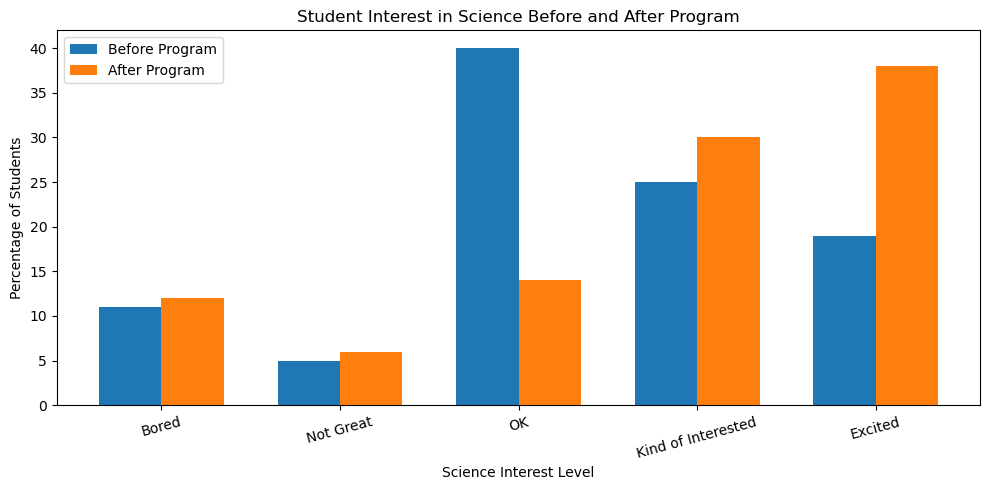

In [104]:
categories = ['Bored', 'Not Great', 'OK', 'Kind of Interested', 'Excited']

before = [11, 5, 40, 25, 19]

after = [12, 6, 14, 30, 38]

x = np.arange(len(categories))

width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x - width/2, before, width, label='Before Program')

plt.bar(x + width/2, after, width, label='After Program')

plt.xlabel('Science Interest Level')

plt.ylabel('Percentage of Students')

plt.title('Student Interest in Science Before and After Program')

plt.xticks(x, categories, rotation=15)

plt.legend()

plt.tight_layout()

plt.show()

### Storytelling With Data Graph

I recreated a graph inspired by the introduction section of *Storytelling With Data* by Cole Nussbaumer Knaflic.

The graph compares student attitudes toward science before and after a pilot program. The visualization shows that the percentage of students who felt "Excited" or "Kind of Interested" increased after the program, while the percentage who felt only "OK" decreased substantially.

I used a grouped bar chart in matplotlib because it allows an easy comparison between the two time periods and clearly communicates the change in student interest levels.